# Tarea 2 
### Matías Arriagada R. | 2022445068 | matiaarriagada2022@udec.cl

El trabajo utiliza `dataset_prueba.csv`, un panel a nivel de ciudad durante la pandemia de COVID-19 (86 ciudades de cinco países europeos, 140 semanas entre febrero de 2020 y octubre de 2022). El objetivo es estimar el efecto de las restricciones gubernamentales sobre la movilidad laboral mediante modelos de datos de panel y, posteriormente, mediante control sintético.


## Estructura del documento

1. Carga, exploración y limpieza de los datos.
2. Pooled OLS.
3. Efectos fijos.
4. Efectos aleatorios.
5. Comparación de los tres estimadores y prueba de Hausman.
6. Efectos aleatorios correlacionados (Mundlak).
7. Modelo preferido e inferencia general.
8. Control sintético.


Cargar librerías y base de datos

Se requieren `linearmodels` (estimadores de panel) y `pysyncon` (control sintético). 

In [1]:
#%pip install -q linearmodels pysyncon

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2

from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel import compare

# Estilo y reproducibilidad centralizados
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11,
                     "axes.titleweight": "semibold", "figure.autolayout": True})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.random.seed(42)

# Paleta consistente por país y colores de marca para todo el documento
PAISES = ["DE", "ES", "FR", "IT", "SE"]
PALETA_PAIS = dict(zip(PAISES, sns.color_palette("Set2", len(PAISES))))
COL_MOV, COL_POL = "#c0392b", "#2c3e50"
print("pandas", pd.__version__)

pandas 2.2.3


## 1. Carga, exploración y limpieza de los datos
### Diccionario de variables
| Columna / Variable | Descripción |
| :--- | :--- |
| **`iso_code`** | Country or region code |
| **`date`** | Date of the record |
| **`retail_and_recreation_percent_change_from_baseline`** | Change in retail/recreation activity |
| **`grocery_and_pharmacy_percent_change_from_baseline`** | Change in grocery/pharmacy activity |
| **`parks_percent_change_from_baseline`** | Change in park visits |
| **`transit_stations_percent_change_from_baseline`** | Change in transit station activity |
| **`workplaces_raw`** | Raw workplace activity data |
| **`residential_percent_change_from_baseline`** | Change in residential activity |
| **`trend`** | Trend indicator |
| **`workplaces`** | Processed workplace activity data |
| **`Valor_Stringency_Index`** | Stringency index value |
| **`Valor_GovernmentResponseIndex`** | Government response index value |
| **`Valor_EconomicSupportIndex`** | Economic support index value |
| **`Valor_Containment_Health_index`** | Containment and health index value |
| **`workplace_closing`** | Workplace closing indicator |
| **`daily_cases`** | Daily reported cases |
| **`week`** | Week number |
| **`year`** | Year |
| **`CODE`** | Region code |
| **`NAME`** | Region name |
| **`Population`** | Population of the region |
| **`agriculture`** | Agriculture sector data |
| **`industry`** | Industry sector data |
| **`construction`** | Construction sector data |
| **`age_dependency`** | Age dependency ratio |
| **`old_age_dependency`** | Old age dependency ratio |
| **`young_age_dependency`** | Young age dependency ratio |
| **`sex_ratio`** | Sex ratio |
| **`unemp`** | Unemployment rate |
| **`f_unemp`** | Female unemployment rate |
| **`m_unemp`** | Male unemployment rate |
| **`foreigners`** | Foreign population percentage |
| **`country`** | Country name |

### Tipos de datos y estructura

La base es un panel balanceado: cada ciudad (`NAME`) se observa en todas las semanas (`week`). Conviven variables continuas (movilidad, índices de política, casos), un identificador temporal (`week`, `year`, `date`)\

Identificadores de unidad (`NAME`, `CODE`, `iso_code`, `country`) y variables sociodemográficas que son constantes en el tiempo para cada ciudad (población, estructura etaria, desempleo, composición sectorial).

Más adelante se realizará una distinción para variables que varían de acuerdo al tiempo y otras variables que quedan fijas.

In [3]:
#Cargas de datos
df = pd.read_csv("dataset_prueba.csv")
df["date"] = pd.to_datetime(df["date"])
print("Dimensiones:", df.shape)
print("Ciudades:", df["NAME"].nunique(), "| Semanas:", df["week"].nunique(),
      "| Países:", sorted(df["country"].unique()))
print("Panel balanceado:", (df.groupby("NAME").size().nunique() == 1),
      "(", df.groupby("NAME").size().iloc[0], "obs. por ciudad )")
df.head()

Dimensiones: (12040, 41)
Ciudades: 86 | Semanas: 140 | Países: ['DE', 'ES', 'FR', 'IT', 'SE']
Panel balanceado: True ( 140 obs. por ciudad )


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0000,3.0000,15.0000,4.0000,1.0000,0.0000,9.2667,4.2441,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
1,DE-BE,2020-02-24,1.6000,0.0000,8.6000,0.0000,0.2000,0.6000,5.0062,2.4683,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
2,DE-BE,2020-03-02,2.6000,6.4000,8.2000,-0.4000,0.4000,1.0000,-3.7654,-2.8454,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
3,DE-BE,2020-03-09,-3.4000,3.4000,-1.0000,-5.8000,-0.6000,1.8000,-12.5370,-11.5103,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
4,DE-BE,2020-03-16,-11.8000,11.4000,-4.6000,-16.0000,-7.8000,4.6000,-21.3086,-21.8009,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE


In [4]:
# Clasificación de variables según su variación temporal dentro de cada ciudad
varia = df.groupby("NAME").nunique(dropna=False)
num = df.select_dtypes("number").columns
invariantes = [c for c in num if (varia[c] <= 1).all()]
temporales = [c for c in num if c not in invariantes]
print("Variables invariantes en el tiempo (nivel ciudad):")
print(" ", ", ".join(invariantes))
print("\nVariables que varían en el tiempo:")
print(" ", ", ".join(temporales))

Variables invariantes en el tiempo (nivel ciudad):
  agriculture, edu2, edu3, age_dependency, old_age_dependency, young_age_dependency, f_unemp, m_unemp

Variables que varían en el tiempo:
  retail_and_recreation_percent_change_from_baseline, grocery_and_pharmacy_percent_change_from_baseline, parks_percent_change_from_baseline, transit_stations_percent_change_from_baseline, workplaces_raw, residential_percent_change_from_baseline, trend, workplaces, Valor_Stringency_Index, Valor_GovernmentResponseIndex, Valor_EconomicSupportIndex, Valor_Containment_Health_index, workplace_closing, daily_cases, d2, d1, d3, d4, d5, d6, week, year, Population, industry, construction, sex_ratio, unemp, foreigners


In [5]:
# Valores faltantes
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print("Columnas con valores faltantes:")
print((na.to_frame("n").assign(pct=(na/len(df)*100).round(1)).to_string()) if len(na) else "  ninguna")

Columnas con valores faltantes:
         n     pct
edu2  5460 45.3000
edu3  5460 45.3000


Estos datos realmente no nos aportan nada al estudio y deberían ser eliminados dado que es casi la mitad de datos que faltan. Lo más sensato será no utilziarlos para el análisis que realizaremos a posterior.

### Estadística descriptiva, distribuciones y valores atípicos

Se examinan la variable dependiente (`workplaces_raw`), la variable de interés (`Valor_Stringency_Index`) y las covariables candidatas. Interesa la forma de cada distribución, la presencia de asimetría y de valores atípicos, y la escala de las variables.

In [6]:
#Estadísticas descriptivas
foco = ["workplaces_raw", "Valor_Stringency_Index", "Valor_EconomicSupportIndex",
        "daily_cases", "Population", "old_age_dependency", "unemp", "foreigners", "industry"]
desc = df[foco].describe().T
desc["skew"] = df[foco].skew()
desc[["mean", "std", "min", "50%", "max", "skew"]].round(2)

,mean,std,min,50%,max,skew
workplaces_raw,-25.0000,14.6800,-87.0000,-22.8000,6.6000,-1.0000
Valor_Stringency_Index,27.4900,29.8400,0.0000,15.8600,93.5200,0.5200
Valor_EconomicSupportIndex,30.9600,36.3600,0.0000,0.0000,100.0000,0.5300
daily_cases,"2,355.7300","3,154.9100",0.0000,632.0100,"22,203.3100",2.1200
Population,745.4700,"1,277.3400",201.0500,346.7900,"10,274.8800",5.3300
old_age_dependency,0.3200,0.0500,0.2600,0.3100,0.4900,1.1900
unemp,12.2200,8.2700,3.0000,8.0000,36.0000,1.0300
foreigners,8.1500,2.9900,2.0000,9.0000,15.0000,-0.1800
industry,0.1200,0.0400,0.0400,0.1100,0.2300,0.3200


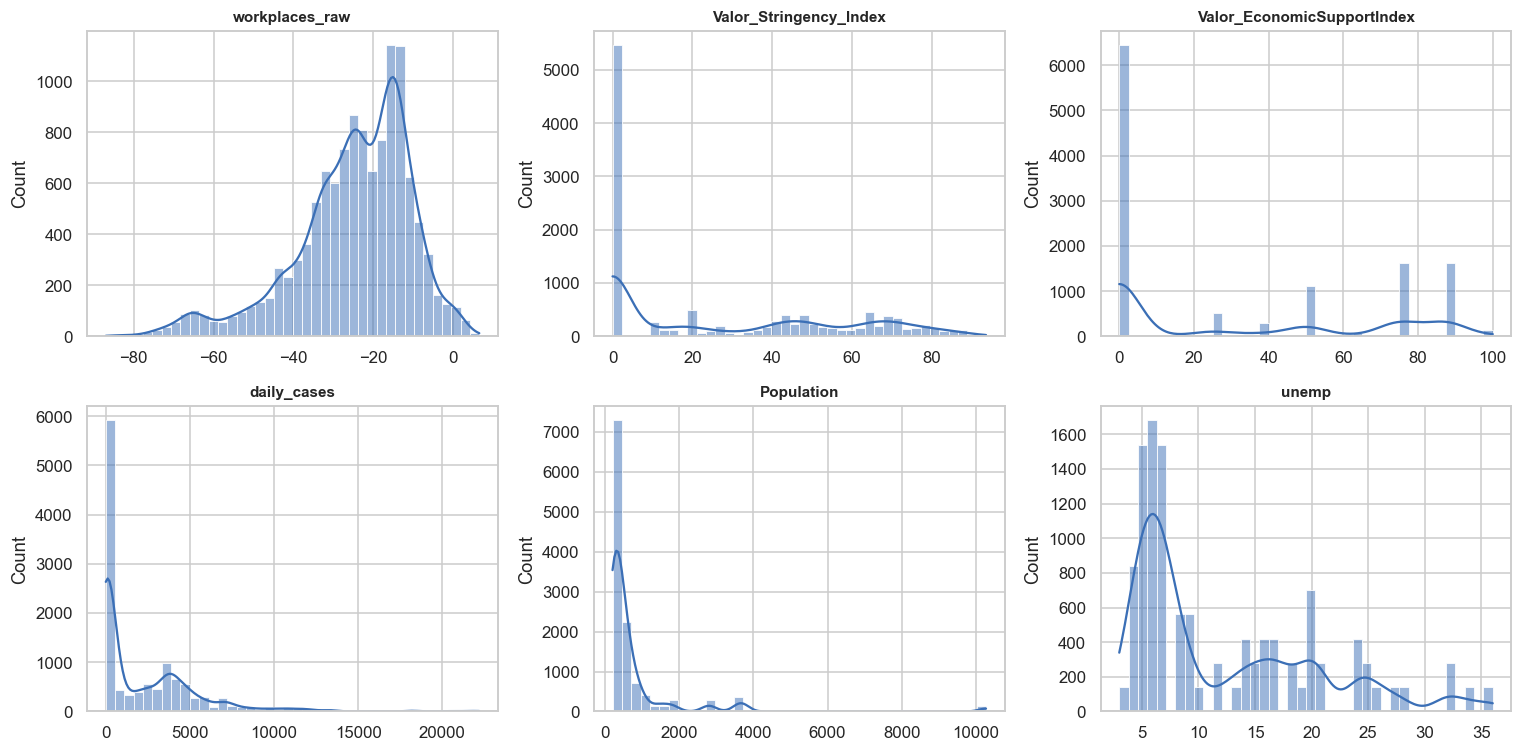

In [7]:
#Visualización de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), ["workplaces_raw", "Valor_Stringency_Index",
        "Valor_EconomicSupportIndex", "daily_cases", "Population", "unemp"]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#3b6fb6")
    ax.set_title(col, fontsize=10); ax.set_xlabel("")
plt.tight_layout(); plt.show()

La movilidad laboral está centrada en valores negativos (caída respecto de la línea base), como cabe esperar en pandemia. `daily_cases` y `Population` presentan fuerte asimetría a la derecha, propia de conteos y de tamaños poblacionales; ambas se transforman con logaritmo para estabilizar la varianza y reducir el apalancamiento de los valores extremos. No se eliminan observaciones por considerarse atípicas: los picos epidémicos y los confinamientos son parte del fenómeno estudiado, no errores de medición.

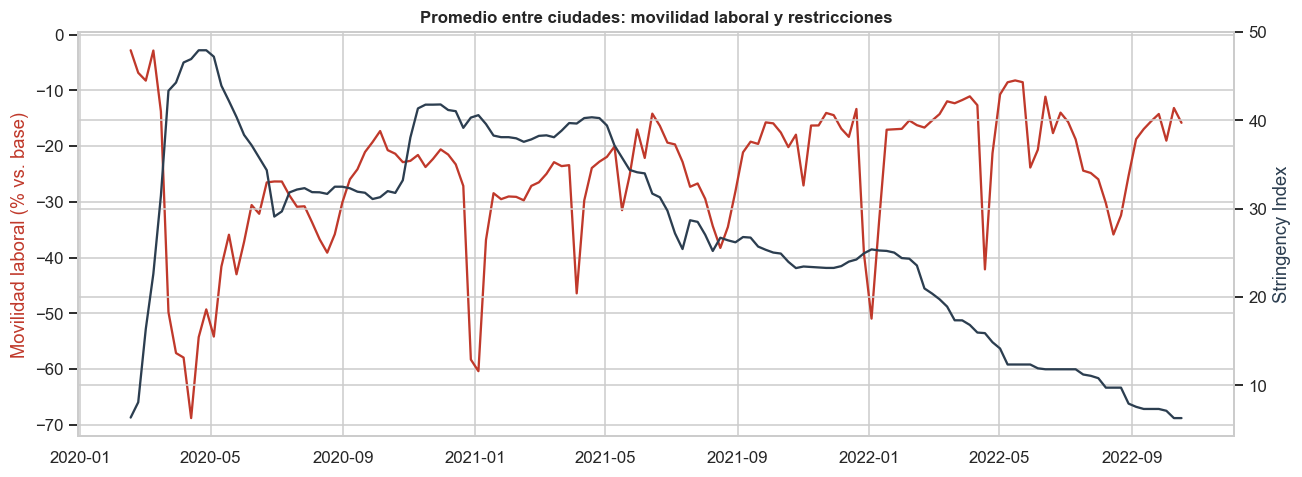

In [8]:
# Transformaciones y limpieza
df["log_pop"] = np.log(df["Population"])
df["log_cases"] = np.log1p(df["daily_cases"])

# Trayectoria temporal de las dos variables centrales (promedio entre ciudades) (gráfico lo saque de la clase :P)
g = df.groupby("date")[["workplaces_raw", "Valor_Stringency_Index"]].mean()
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(g.index, g["workplaces_raw"], color="#c0392b", label="Movilidad laboral")
ax1.set_ylabel("Movilidad laboral (% vs. base)", color="#c0392b")
ax2 = ax1.twinx()
ax2.plot(g.index, g["Valor_Stringency_Index"], color="#2c3e50", label="Stringency Index")
ax2.set_ylabel("Stringency Index", color="#2c3e50")
ax1.set_title("Promedio entre ciudades: movilidad laboral y restricciones")
plt.tight_layout(); plt.show()

La relación es claramente inversa: los picos de restricción coinciden con las mayores caídas de movilidad laboral, y la relajación posterior con su recuperación. Esta correlación agregada motiva la estimación formal, que debe separar el efecto de la política de la respuesta voluntaria de la población a la propia evolución epidémica. Dentro de las caídas cabe destacar que hay cierta relació con posibles dias festivos, como año nuevo en cada 01 de cada año.

### Correlaciones y multicolinealidad

Antes de estimar conviene revisar la estructura de correlaciones entre los regresores. La movilidad laboral correlaciona de forma negativa con el *Stringency Index*, en línea con la hipótesis. Entre los regresores no aparece colinealidad severa una vez excluidos los índices de política redundantes, lo que respalda la selección de variables del modelo.

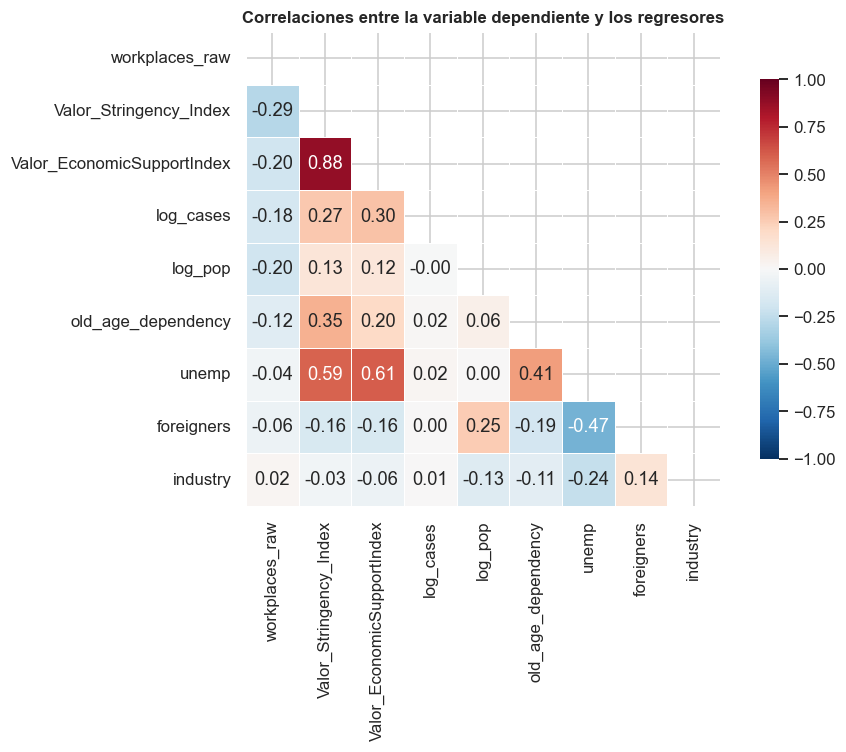

In [9]:
vars_corr = ["workplaces_raw", "Valor_Stringency_Index", "Valor_EconomicSupportIndex",
             "log_cases", "log_pop", "old_age_dependency", "unemp", "foreigners", "industry"]
corr = df[vars_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlaciones entre la variable dependiente y los regresores")
plt.show()

Dentro de la interpretación de este gráfico, podemos ver que dentro de la econometría común posee ciertos comportamientos logícos dentro de la data. Se observa cierta relación directa entre *Stringency Index* y *Economic Support Index*, siendo medidas promovidas en relación bajo la instauración de politicas publicas. Adicionalmente podemos ver que dentro del desempleo, este posee un comportamiento directo con la medida de resguardo por las autoridades.

### Heterogeneidad entre países

El promedio entre ciudades oculta diferencias relevantes entre países, que provienen de calendarios y severidades de política distintos. Las siguientes vistas muestran esa heterogeneidad: motiva el uso de efectos fijos (que la absorben) y la elección del *donor pool* para el control sintético. Observamos que posee el mismo patrón que el gráfico señalado anteriormente.

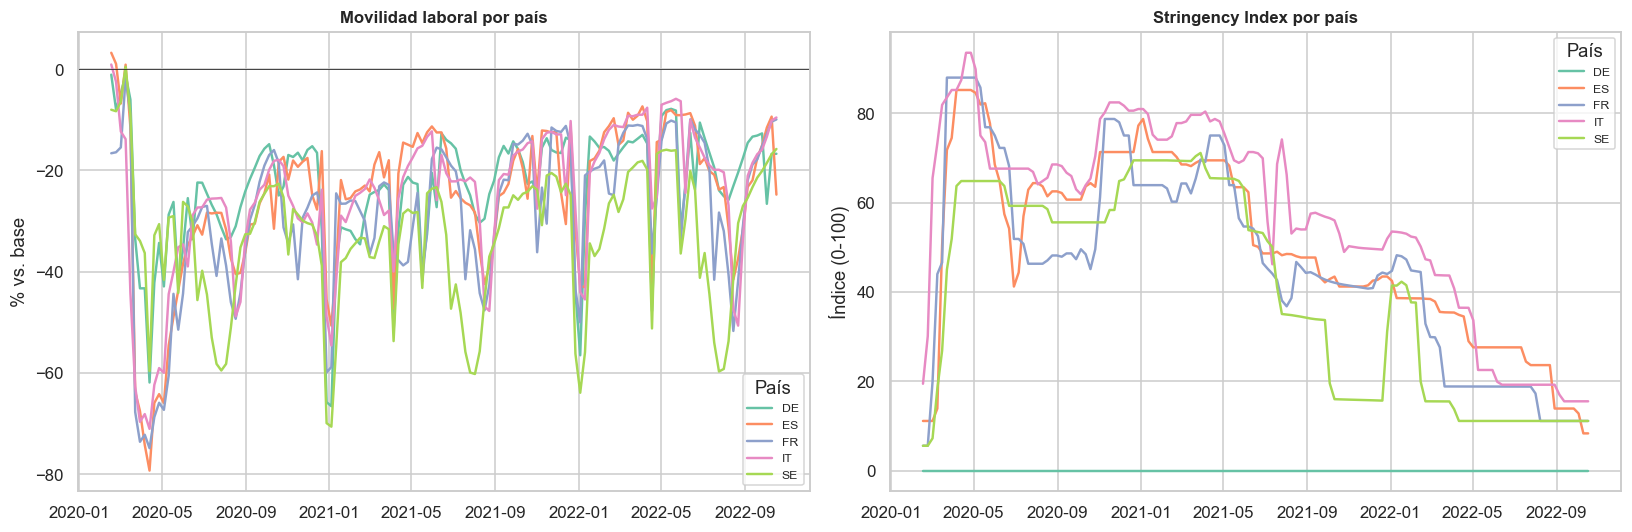

In [10]:
paises = sorted(df["country"].unique())
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for p in paises:
    s = df[df["country"] == p].groupby("date")[["workplaces_raw", "Valor_Stringency_Index"]].mean()
    axes[0].plot(s.index, s["workplaces_raw"], color=PALETA_PAIS[p], label=p, lw=1.6)
    axes[1].plot(s.index, s["Valor_Stringency_Index"], color=PALETA_PAIS[p], label=p, lw=1.6)
axes[0].set_title("Movilidad laboral por país"); axes[0].set_ylabel("% vs. base"); axes[0].axhline(0, color="k", lw=.5)
axes[1].set_title("Stringency Index por país"); axes[1].set_ylabel("Índice (0-100)")
for a in axes: a.legend(title="País", fontsize=8)
plt.show()

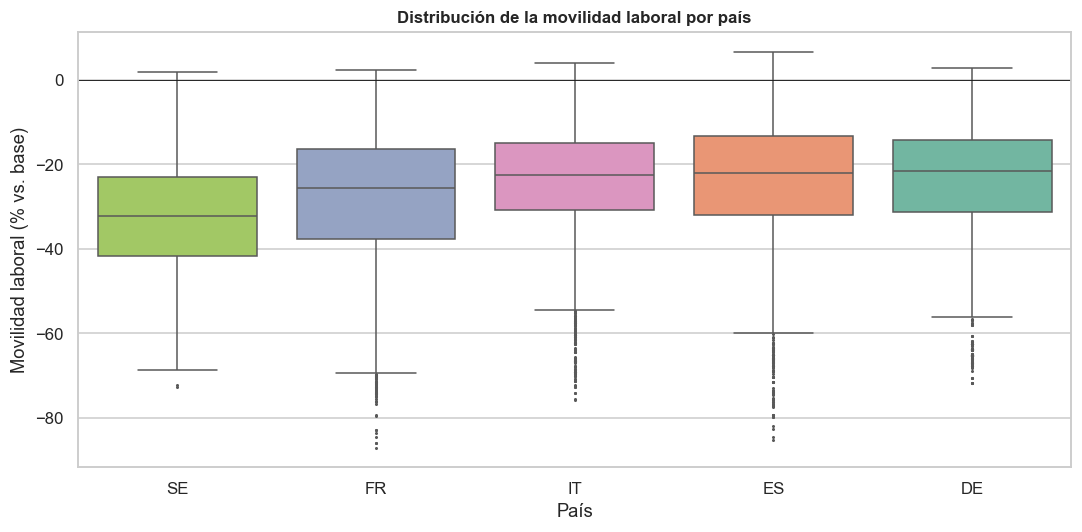

In [11]:
orden = df.groupby("country")["workplaces_raw"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="country", y="workplaces_raw", order=orden,
            palette=[PALETA_PAIS[p] for p in orden], ax=ax, fliersize=1)
ax.axhline(0, color="k", lw=.6)
ax.set_title("Distribución de la movilidad laboral por país")
ax.set_xlabel("País"); ax.set_ylabel("Movilidad laboral (% vs. base)")
plt.show()

In [12]:
# Definición del panel y de las variables del modelo
panel = df.set_index(["NAME", "week"]).sort_index()

DEP = "workplaces_raw"                      # movilidad laboral (variable dependiente)
TRAT = "Valor_Stringency_Index"             # restricciones (variable de interés)
TIEMPO = ["Valor_Stringency_Index", "log_cases", "Valor_EconomicSupportIndex"]  # varían en el tiempo
INVAR = ["log_pop", "old_age_dependency", "unemp", "foreigners", "industry"]     # invariantes en el tiempo
print("Dependiente:", DEP)
print("Regresores que varían en el tiempo:", TIEMPO)
print("Controles invariantes en el tiempo:", INVAR)

# Rezago de la variable dependiente (persistencia), por ciudad y ordenado por semana.
# Forma recomendada de modelar el tiempo a frecuencia semanal (en vez de dummies de periodo).
panel["L1_workplaces"] = panel.groupby(level=0)[DEP].shift(1)
print("Rezago L1 disponible en", int(panel["L1_workplaces"].notna().sum()), "de", len(panel), "obs.")

Dependiente: workplaces_raw
Regresores que varían en el tiempo: ['Valor_Stringency_Index', 'log_cases', 'Valor_EconomicSupportIndex']
Controles invariantes en el tiempo: ['log_pop', 'old_age_dependency', 'unemp', 'foreigners', 'industry']
Rezago L1 disponible en 11954 de 12040 obs.


### Selección de variables

La variable de interés es el *Stringency Index*, que resume la intensidad de las restricciones gubernamentales (hay otras variables que están relacionados con esta variable). Como controles que varían en el tiempo se incluyen el logaritmo de los casos diarios (la población reduce su movilidad de forma voluntaria ante el aumento de contagios, con independencia de la política, lo que constituye un confusor temporal) y el índice de apoyo económico (que puede alterar la necesidad de desplazarse al trabajo). Como controles invariantes en el tiempo se incluyen el tamaño poblacional, la dependencia de la población mayor, el desempleo, el porcentaje de población extranjera y el peso de la industria; estas variables capturan diferencias estructurales entre ciudades que importan en los modelos pooled y de efectos aleatorios pero que desaparecen en efectos fijos. Se evita incluir simultáneamente índices de política muy colineales entre sí (`GovernmentResponse`, `Containment`), que son casi una recodificación del *Stringency Index*.

### Variación entre ciudades frente a variación dentro de cada ciudad

Un panel contiene dos fuentes de variación: la que ocurre *entre* ciudades (diferencias de nivel, fijas en el tiempo) y la que ocurre *dentro* de cada ciudad a lo largo del tiempo. El estimador de efectos fijos descarta la primera y se apoya solo en la segunda. La descomposición siguiente cuantifica cuánta varianza es de cada tipo, y el gráfico muestra la relación *within* (variables centradas en su media por ciudad) entre restricciones y movilidad laboral, cuya pendiente se aproxima al coeficiente de efectos fijos.

                        % entre ciudades  % dentro de la ciudad
workplaces_raw                    9.2000                90.8000
Valor_Stringency_Index           71.8000                28.2000
log_cases                         0.3000                99.7000


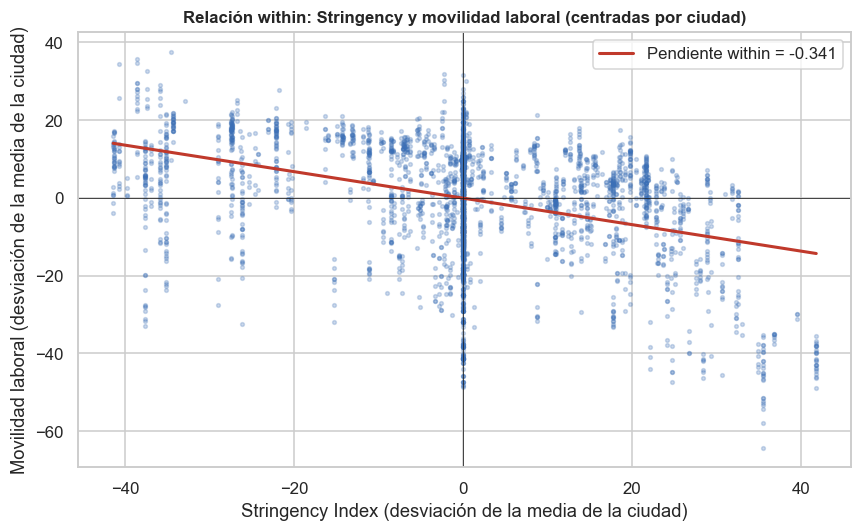

In [13]:
#Realizamos una descomposición de la varianza para entender mejor la estructura del panel entre ciudades y dentro de cada ciudad
def descomp_var(v):
    medias_c = panel.groupby(level=0)[v].transform("mean")
    entre = medias_c.var()
    dentro = (panel[v] - medias_c).var()
    return pd.Series({"% entre ciudades": 100 * entre / (entre + dentro),
                      "% dentro de la ciudad": 100 * dentro / (entre + dentro)})
tabla_wb = pd.DataFrame({v: descomp_var(v) for v in [DEP, TRAT, "log_cases"]}).T.round(1)
print(tabla_wb.to_string())

# Relación within: variables centradas en la media de cada ciudad
wy = panel[DEP] - panel.groupby(level=0)[DEP].transform("mean")
wx = panel[TRAT] - panel.groupby(level=0)[TRAT].transform("mean")
muestra = np.random.choice(len(wx), size=min(4000, len(wx)), replace=False)
b, a = np.polyfit(wx.values[muestra], wy.values[muestra], 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(wx.values[muestra], wy.values[muestra], s=6, alpha=.25, color="#3b6fb6")
xg = np.linspace(wx.min(), wx.max(), 50)
ax.plot(xg, a + b * xg, color=COL_MOV, lw=2, label=f"Pendiente within = {b:.3f}")
ax.set_title("Relación within: Stringency y movilidad laboral (centradas por ciudad)")
ax.set_xlabel("Stringency Index (desviación de la media de la ciudad)")
ax.set_ylabel("Movilidad laboral (desviación de la media de la ciudad)")
ax.axhline(0, color="k", lw=.5); ax.axvline(0, color="k", lw=.5); ax.legend()
plt.show()

## 2. Pooled OLS

El estimador *pooled* trata todas las observaciones ciudad-semana como si fueran independientes y estima por mínimos cuadrados ordinarios, a continuación se tiene el modelo:

$$y_{it} = \alpha + \beta\, \text{Stringency}_{it} + \mathbf{x}_{it}'\boldsymbol{\gamma} + u_{it}.$$

Ignora la estructura de panel: supone que no existe heterogeneidad no observada a nivel de ciudad, o equivalentemente que el componente individual $c_i$ no está correlacionado con los regresores y se confunde con el error. Como las observaciones de una misma ciudad están correlacionadas en el tiempo, se emplean errores estándar agrupados (*cluster*) por ciudad para no subestimar la incertidumbre. Cabe destacar que tengo una observación dentro de la configuración de covarianza, consideraba usar HC1, pero en el ajuste se me fue recomendada *clustered*

In [14]:
X_pool = sm.add_constant(panel[TIEMPO + INVAR])
pooled = PooledOLS(panel[DEP], X_pool).fit(cov_type="clustered", cluster_entity=True)
print(pooled.summary.tables[1])
print("\nR2:", round(pooled.rsquared, 3))

                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                         -3.0673     5.0238    -0.6105     0.5415     -12.915      6.7802
Valor_Stringency_Index        -0.2500     0.0242    -10.328     0.0000     -0.2975     -0.2026
log_cases                     -0.4526     0.0835    -5.4209     0.0000     -0.6162     -0.2889
Valor_EconomicSupportIndex     0.0880     0.0294     2.9945     0.0028      0.0304      0.1456
log_pop                       -2.6825     0.6222    -4.3116     0.0000     -3.9020     -1.4629
old_age_dependency            -8.5897     7.1950    -1.1938     0.2326     -22.693      5.5137
unemp                          0.2557     0.0868     2.9478     0.0032      0.0857      0.4258
foreigners                    -0.0647     0.1664  

El coeficiente del *Stringency Index* es -0.25, negativo y significativo: un aumento de diez puntos en el índice se asocia con una caída de unos 2.5 puntos porcentuales en la movilidad laboral. Las variables estructurales (población, dependencia de mayores, peso industrial) resultan significativas, pero su interpretación es delicada: el estimador pooled atribuye a esas características diferencias que podrían deberse a heterogeneidad no observada. Este es precisamente el supuesto que relajan los modelos de panel.

Interpretación por variable:
- `Valor_Stringency_Index` = -0.25$: por cada punto adicional de rigidez, la movilidad laboral cae 0.25 pp.
- `log_cases` = -0.45$: a más casos, menor movilidad (respuesta voluntaria de aversión al contagio).
- `Valor_EconomicSupportIndex` = 0.09$: un punto más de apoyo económico se asocia a un leve aumento de la movilidad.

El tratamiento del tiempo se aborda más adelante con el two-way FE (dummies de periodo) y, sobre todo, con un modelo dinámico de persistencia (rezago de la dependiente, según la recomendaicón de Teams), que es lo recomendado a esta frecuencia. En teoría este modelo nos puede arrojar un beta sesgado y hay que continuar a otros que eliminen ese sesgo.

## 3. Efectos fijos

El modelo de efectos fijos descompone el error en un componente individual invariante en el tiempo $c_i$ y un término $\varepsilon_{it}$:

$$y_{it} = \beta\, \text{Stringency}_{it} + \mathbf{x}_{it}'\boldsymbol{\gamma} + c_i + \varepsilon_{it}.$$

La estimación *within* equivale a restar a cada variable su media temporal por ciudad, eliminando $c_i$. La gran ventaja es que $\beta$ se identifica solo con la variación dentro de cada ciudad a lo largo del tiempo, de modo que cualquier característica fija de la ciudad observada o no queda controlada. El costo es que los regresores invariantes en el tiempo no pueden estimarse, pues se anulan en la transformación. Se reporta también la especificación con efectos fijos de ciudad y de tiempo (two-way), que además absorbe choques comunes a todas las ciudades en cada semana (estacionalidad, evolución general de la pandemia).

In [15]:
X_fe = sm.add_constant(panel[TIEMPO])
fe = PanelOLS(panel[DEP], X_fe, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print(fe.summary.tables[1])
print("\nR2 within:", round(fe.rsquared_within, 3))

                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                         -15.186     0.3685    -41.209     0.0000     -15.909     -14.464
Valor_Stringency_Index        -0.3866     0.0221    -17.517     0.0000     -0.4298     -0.3433
log_cases                      0.0110     0.1256     0.0877     0.9301     -0.2352      0.2573
Valor_EconomicSupportIndex     0.0242     0.0270     0.8971     0.3697     -0.0287      0.0771

R2 within: 0.17


In [16]:
fe_tw = PanelOLS(panel[DEP], X_fe, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)
print("Efectos fijos de ciudad y de tiempo (two-way):")
print(fe_tw.summary.tables[1])

Efectos fijos de ciudad y de tiempo (two-way):
                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                         -1.2209     3.9139    -0.3119     0.7551     -8.8927      6.4510
Valor_Stringency_Index        -0.0900     0.0079    -11.452     0.0000     -0.1054     -0.0746
log_cases                     -4.0277     0.7629    -5.2796     0.0000     -5.5230     -2.5323
Valor_EconomicSupportIndex     0.0075     0.0128     0.5903     0.5550     -0.0175      0.0325


Con efectos de entidad, el coeficiente del *Stringency Index* sube a -0.39: al descontar la heterogeneidad fija entre ciudades, la relación se intensifica respecto del pooled. En la especificación two-way (efectos de ciudad y de tiempo) el coeficiente baja a -0.09, porque las dummies de periodo absorben la dinámica europea común de la pandemia. Este modelo de efectos fijos de dos vías (*two-way fixed effects*) es la forma estándar y correcta de incorporar el tiempo en el FE; su contrapartida es que, al absorber toda la variación temporal común, tiende a aplanar la dinámica, por lo que más adelante se complementa con un modelo dinámico de persistencia.

Un matiz: en el two-way, `log_cases` pasa a  -4.0$ y muy significativo, capturando que las desviaciones de casos de una ciudad respecto del promedio europeo de cada semana sí reducen su movilidad (efecto *within*).

## 4. Efectos aleatorios

El modelo de efectos aleatorios mantiene el componente individual $c_i$ pero supone que es ortogonal a los regresores, $\operatorname{Cov}(c_i, \mathbf{x}_{it}) = 0$, y lo trata como parte del error con una estructura de covarianzas conocida. Estima por mínimos cuadrados generalizados, lo que equivale a una transformación cuasi-*within* gobernada por un parámetro $\theta \in [0,1]$: con $\theta=0$ se recupera el pooled y con $\theta=1$ el *within*. Si el supuesto de ortogonalidad se cumple, el estimador es más eficiente que efectos fijos y, además, permite estimar los regresores invariantes en el tiempo.

In [17]:
X_re = sm.add_constant(panel[TIEMPO + INVAR])
re = RandomEffects(panel[DEP], X_re).fit(cov_type="clustered", cluster_entity=True)
print(re.summary.tables[1])
print("\ntheta (medio):", round(float(np.asarray(re.theta).mean()), 3))

                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                         -13.559     6.4061    -2.1166     0.0343     -26.116     -1.0019
Valor_Stringency_Index        -0.3449     0.0219    -15.784     0.0000     -0.3878     -0.3021
log_cases                     -0.1255     0.1136    -1.1043     0.2695     -0.3482      0.0972
Valor_EconomicSupportIndex     0.0409     0.0281     1.4555     0.1456     -0.0142      0.0960
log_pop                       -2.3344     0.8844    -2.6396     0.0083     -4.0678     -0.6009
old_age_dependency            -4.1724     10.244    -0.4073     0.6838     -24.252      15.907
unemp                          0.6494     0.1008     6.4417     0.0000      0.4518      0.8471
foreigners                     0.3390     0.2582  

Con $\theta = 0.63$, el estimador de efectos aleatorios pondera de forma intermedia entre el pooled ($\theta=0$) y el *within* ($\theta=1$): descuenta buena parte de la media de ciudad, pero no toda. El coeficiente del *Stringency Index* (-0.34) queda entre el del pooled (-0.25) y el de efectos fijos de entidad (-0.39), lo cuál quixás sea logíco debido al componente entre ambos modelos. A diferencia de efectos fijos, RE sí estima las variables invariantes en el tiempo, aunque su validez depende del supuesto de ortogonalidad $\operatorname{Cov}(c_i,\mathbf{x}_{it})=0$, que se contrasta a continuación.

## 5. Comparación de estimadores y prueba de Hausman

Las diferencias entre los tres estimadores provienen del tratamiento del componente no observado $c_i$:

- El pooled supone que $c_i$ no existe (o no se correlaciona con los regresores) y no la descuenta. Si $c_i$ se correlaciona con la política, el coeficiente está sesgado por variable omitida.
- Los efectos fijos eliminan $c_i$ por completo; son consistentes aunque $c_i$ se correlacione con los regresores, a costa de eficiencia y de no estimar lo invariante en el tiempo.
- Los efectos aleatorios descuentan $c_i$ parcialmente bajo el supuesto de ortogonalidad; son eficientes solo si ese supuesto se cumple.

La prueba de Hausman contrasta $H_0:\operatorname{Cov}(c_i,\mathbf{x}_{it})=0$. Bajo $H_0$, efectos fijos y aleatorios son ambos consistentes y deben coincidir; si difieren sistemáticamente, se rechaza $H_0$ y se prefiere efectos fijos. El estadístico es

$$H = (\hat\beta_{FE}-\hat\beta_{RE})'\,[\widehat{\operatorname{Var}}(\hat\beta_{FE})-\widehat{\operatorname{Var}}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE}-\hat\beta_{RE}) \sim \chi^2_k.$$

In [18]:
print(compare({"Pooled OLS": pooled, "Efectos fijos": fe, "Efectos aleatorios": re},
              precision="std_errors"))

                                    Model Comparison                                   
                                       Pooled OLS      Efectos fijos Efectos aleatorios
---------------------------------------------------------------------------------------
Dep. Variable                      workplaces_raw     workplaces_raw     workplaces_raw
Estimator                               PooledOLS           PanelOLS      RandomEffects
No. Observations                            12040              12040              12040
Cov. Est.                               Clustered          Clustered          Clustered
R-squared                                  0.1511             0.1703             0.1583
R-Squared (Within)                         0.1314             0.1703             0.1679
R-Squared (Between)                        0.3457            -2.8425            -0.5337
R-Squared (Overall)                        0.1511            -0.1072             0.1033
F-statistic                     

El gráfico de coeficientes resume la robustez del efecto. El *Stringency Index* es negativo y su intervalo de confianza al 95% excluye el cero en las cuatro especificaciones. La magnitud crece del pooled (-0.25) al FE de entidad (-0.39) al descontar la heterogeneidad entre ciudades y se modera en el two-way FE (-0.09), que absorbe con dummies de periodo la dinámica común de la pandemia.

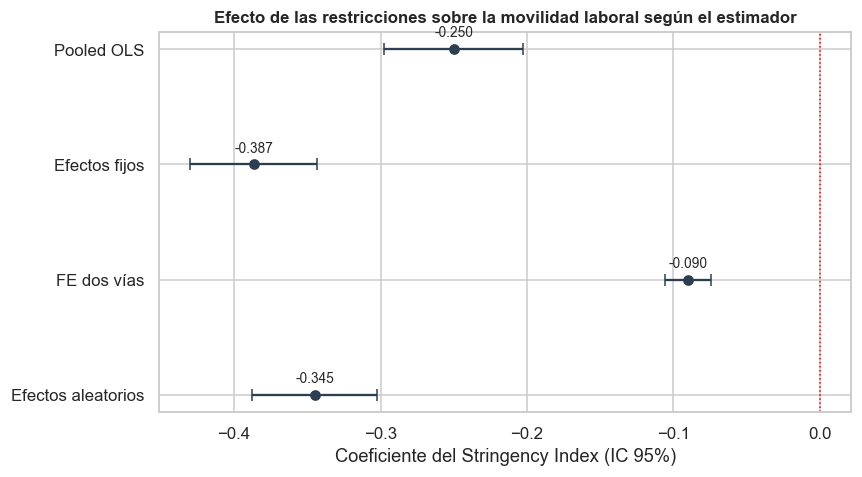

In [19]:
modelos = {"Pooled OLS": pooled, "Efectos fijos": fe, "FE dos vías": fe_tw, "Efectos aleatorios": re}
fig, ax = plt.subplots(figsize=(8, 4.5))
for j, (nombre, res) in enumerate(modelos.items()):
    b = res.params[TRAT]; se = res.std_errors[TRAT]
    ax.errorbar(b, j, xerr=1.96 * se, fmt="o", color=COL_POL, capsize=4)
    ax.annotate(f"{b:.3f}", (b, j), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.axvline(0, color="red", ls=":", lw=1)
ax.set_yticks(range(len(modelos))); ax.set_yticklabels(list(modelos.keys()))
ax.invert_yaxis()
ax.set_xlabel("Coeficiente del Stringency Index (IC 95%)")
ax.set_title("Efecto de las restricciones sobre la movilidad laboral según el estimador")
plt.show()

In [20]:
# Prueba de Hausman (covarianza no robusta: RE debe ser eficiente bajo H0)
fe_h = PanelOLS(panel[DEP], X_fe, entity_effects=True).fit()
re_h = RandomEffects(panel[DEP], sm.add_constant(panel[TIEMPO + INVAR])).fit()
b = fe_h.params[TIEMPO] - re_h.params[TIEMPO]
V = fe_h.cov.loc[TIEMPO, TIEMPO].values - re_h.cov.loc[TIEMPO, TIEMPO].values
H = float(b.values @ np.linalg.inv(V) @ b.values)
print(f"Estadístico de Hausman = {H:.2f}  |  gl = {len(TIEMPO)}  |  p = {chi2.sf(H, len(TIEMPO)):.3g}")
print("Conclusión:", "se rechaza H0 -> se prefiere efectos fijos" if chi2.sf(H, len(TIEMPO)) < 0.05
      else "no se rechaza H0 -> efectos aleatorios es admisible")

Estadístico de Hausman = 284.31  |  gl = 3  |  p = 2.48e-61
Conclusión: se rechaza H0 -> se prefiere efectos fijos


La tabla comparativa muestra que el coeficiente del *Stringency Index* es robusto en signo y orden de magnitud a través de las tres especificaciones: las restricciones reducen la movilidad laboral en todos los casos. Lo que cambia es la magnitud, que crece a medida que se descuenta más la heterogeneidad de ciudad, y la estimación de las variables estructurales, disponibles solo en pooled y efectos aleatorios.

La prueba de Hausman rechaza con holgura la hipótesis nula de ortogonalidad: el componente no observado de cada ciudad está correlacionado con los regresores, por lo que el estimador de efectos aleatorios es inconsistente y se prefiere efectos fijos. Las variables robustas a la especificación son el *Stringency Index* (siempre negativo y significativo) y, en menor medida, los casos diarios. Me quedo pendiente ver lo de la autocorrelación.

## 6. Efectos aleatorios correlacionados (Mundlak)

El enfoque de Mundlak relaja el supuesto de ortogonalidad de efectos aleatorios modelando explícitamente la correlación entre el componente individual y los regresores. Se postula $c_i = \bar{\mathbf{x}}_i'\boldsymbol{\lambda} + a_i$, donde $\bar{\mathbf{x}}_i$ son las medias temporales por ciudad de los regresores que varían en el tiempo y $a_i$ es ortogonal por construcción. Sustituyendo, se estima por efectos aleatorios el modelo aumentado

$$y_{it} = \beta\, \text{Stringency}_{it} + \mathbf{x}_{it}'\boldsymbol{\gamma} + \bar{\mathbf{x}}_i'\boldsymbol{\lambda} + a_i + \varepsilon_{it}.$$

Dos propiedades hacen útil este modelo. Primero, el coeficiente de cada variable que varía en el tiempo coincide con el de efectos fijos, de modo que se recupera la estimación *within* sin perder la posibilidad de incluir variables invariantes en el tiempo. Segundo, la significancia conjunta de las medias $\boldsymbol{\lambda}$ constituye una prueba de Hausman robusta: si $\boldsymbol{\lambda}=0$, no hay correlación con el efecto no observado y efectos aleatorios sería válido.

In [21]:
medias = panel.groupby(level=0)[TIEMPO].transform("mean")
medias.columns = [c + "_media" for c in TIEMPO]
cre_df = pd.concat([panel[[DEP] + TIEMPO + INVAR], medias], axis=1)
X_cre = sm.add_constant(cre_df[TIEMPO + INVAR + list(medias.columns)])
cre = RandomEffects(cre_df[DEP], X_cre).fit(cov_type="clustered", cluster_entity=True)
print(cre.summary.tables[1])

                                        Parameter Estimates                                         
                                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------------
const                               -12.738     11.894    -1.0710     0.2842     -36.053      10.576
Valor_Stringency_Index              -0.3863     0.0220    -17.539     0.0000     -0.4295     -0.3431
log_cases                            0.0112     0.1253     0.0896     0.9286     -0.2344      0.2568
Valor_EconomicSupportIndex           0.0241     0.0270     0.8920     0.3724     -0.0289      0.0771
log_pop                             -3.3251     0.5505    -6.0402     0.0000     -4.4042     -2.2460
old_age_dependency                  -16.763     9.2478    -1.8127     0.0699     -34.890      1.3638
unemp                               -0.0213     0.0759    -0.2807     0.7789     -0.1700   

In [22]:
# Verificación: el coeficiente within del CRE coincide con el de efectos fijos (entidad)
chequeo = pd.DataFrame({
    "Efectos fijos": fe.params[TIEMPO],
    "CRE (within)": cre.params[TIEMPO]}).round(4)
print(chequeo.to_string())

# Prueba de Hausman robusta: significancia conjunta de las medias de Mundlak
mcols = list(medias.columns)
bm = cre.params[mcols].values
Vm = cre.cov.loc[mcols, mcols].values
W = float(bm @ np.linalg.inv(Vm) @ bm)
print(f"\nWald conjunto sobre las medias de Mundlak: chi2 = {W:.2f}, gl = {len(mcols)}, p = {chi2.sf(W, len(mcols)):.3g}")

                            Efectos fijos  CRE (within)
Valor_Stringency_Index            -0.3866       -0.3863
log_cases                          0.0110        0.0112
Valor_EconomicSupportIndex         0.0242        0.0241

Wald conjunto sobre las medias de Mundlak: chi2 = 218.36, gl = 3, p = 4.54e-47


Los coeficientes *within* del modelo de Mundlak reproducen exactamente los de efectos fijos de entidad (-0.39 para el *Stringency Index*), al incluir las medias por ciudad, el CRE recupera la estimación de efectos fijos sin perder la posibilidad de incluir variables invariantes. Las medias por ciudad son conjuntamente significativas (Wald de Mundlak con $p<0.001$), lo que confirma de forma robusta el rechazo de la ortogonalidad: existe correlación entre las características promedio de cada ciudad y su componente no observado.

Sobre la adecuación del modelo: Mundlak aproxima $c_i$ como función lineal de las medias temporales de los regresores, lo cual es útil pero limitado. Como los efectos fijos ya eliminan $c_i$ sin imponer esa forma funcional, el valor principal del CRE aquí es diagnóstico.

## 6.b Modelo dinámico: persistencia con rezago de la dependiente

Esto lo ajuste a una nueva configuración de acuerdo a lo comnetado. A frecuencia semanal, la forma natural de modelar el tiempo es incluir un rezago de la variable dependiente (persistencia) en lugar de dummies de periodo: las dummies tienden a aplanar la dinámica en una tendencia, mientras que el rezago conserva los movimientos de alza y baja. El modelo es

$$y_{it} = \rho\, y_{i,t-1} + \beta\,\text{Stringency}_{it} + \mathbf{x}_{it}'\boldsymbol{\gamma} + c_i + \varepsilon_{it}.$$

$\rho$ mide la persistencia. El efecto de corto plazo del *Stringency* es $\beta$; el de largo plazo (acumulado) es $\beta/(1-\rho)$. Un rezago bajo efectos fijos genera un sesgo de Nickell de orden $1/T$, despreciable aquí con $T=140$.

In [23]:
panel_d = panel.dropna(subset=["L1_workplaces"])
X_dyn = sm.add_constant(panel_d[["L1_workplaces"] + TIEMPO])
dyn = PanelOLS(panel_d[DEP], X_dyn, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print(dyn.summary.tables[1])

rho = dyn.params["L1_workplaces"]; b = dyn.params[TRAT]
print(f"\nPersistencia (rho)                   = {rho:.3f}")
print(f"Efecto de corto plazo del Stringency = {b:.4f}")
print(f"Efecto de largo plazo del Stringency = {b/(1-rho):.4f}")

                                     Parameter Estimates                                      
                            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------------
const                         -5.2110     0.1211    -43.048     0.0000     -5.4483     -4.9738
L1_workplaces                  0.6766     0.0053     128.45     0.0000      0.6663      0.6870
Valor_Stringency_Index        -0.1617     0.0085    -19.090     0.0000     -0.1783     -0.1451
log_cases                      0.1104     0.0477     2.3137     0.0207      0.0169      0.2038
Valor_EconomicSupportIndex     0.0284     0.0118     2.4076     0.0161      0.0053      0.0515

Persistencia (rho)                   = 0.677
Efecto de corto plazo del Stringency = -0.1617
Efecto de largo plazo del Stringency = -0.5000


La movilidad laboral es muy persistente: $\rho = 0.68$ (unos dos tercios del nivel de una semana se trasladan a la siguiente). El efecto de corto plazo del *Stringency* es -0.16 (diez puntos más de rigidez reducen la movilidad laboral 1.6 pp esa misma semana) y el de largo plazo es $\beta/(1-\rho) ? -0.50 (unos 5 pp una vez que la dinámica se propaga). Esta especificación conserva los movimientos de alza y baja que las dummies de periodo aplanarían, y sitúa el efecto entre el FE de entidad (-0.39) y el two-way (-0.09).

## 7. Modelo preferido e inferencia general

La prueba de Hausman y el contraste de Mundlak coinciden en rechazar el supuesto de ortogonalidad, por lo que el estimador de efectos aleatorios es inconsistente para estos datos (lo habiamos mencionado antes). Entre los modelos restantes se prefiere el de efectos fijos, idealmente en su versión con efectos de ciudad y de tiempo, porque controla simultáneamente toda la heterogeneidad estructural entre ciudades y los choques comunes por semana, dejando como fuente de identificación únicamente la variación de la política dentro de cada ciudad a lo largo del tiempo.

La inferencia general es consistente entre especificaciones: las restricciones gubernamentales reducen la movilidad laboral, y el efecto es estadísticamente significativo y económicamente relevante. El efecto del *Stringency Index* es negativo y significativo en todas las especificaciones. Su magnitud depende de cómo se trate el tiempo: -0.39 en el FE de entidad, -0.09 en el two-way FE, y en el modelo dinámico de persistencia -0.16 de corto plazo y -0.50 de largo plazo. A frecuencia semanal, el modelo dinámico es la forma más informativa de capturar el efecto sin aplanar los movimientos de alza y baja. No obstante, esta estimación sigue expuesta a un problema de simultaneidad temporal: la política y la movilidad evolucionan de forma dinámica y conjunta, y los gobiernos endurecen las restricciones en respuesta a la propia evolución de la pandemia. La sección siguiente aborda esa limitación con un diseño.


### Diseño

Dentro de la investigación que realice, me la IA recomendó una ciudad en especifica, como unidad tratada se elige Milano. Italia fue el epicentro europeo de la primera ola y decretó el confinamiento nacional el 9 de marzo de 2020 (semana 4 del panel), antes y con mayor severidad que el resto de los países de la muestra. El *Stringency Index* es un índice nacional, de modo que la intervención se interpreta como la política italiana. El *donor pool* se forma con las ciudades de los demás países (Alemania, España, Francia y Suecia), que no estaban sujetas a la política italiana en esa fecha y sirven como controles. La variable de resultado es la movilidad laboral (`workplaces_raw`); los predictores combinan características sociodemográficas y la trayectoria pre-tratamiento de la movilidad.

In [24]:
from pysyncon import Dataprep, Synth, PenalizedSynth

CIUDAD_TRATADA = "Milano"
SEMANA_TRAT = 4   # 2020-03-09, confinamiento nacional italiano
donantes = [c for c in df[df["country"] != "IT"]["NAME"].unique()]
print("Unidad tratada:", CIUDAD_TRATADA)
print("Semana de tratamiento:", SEMANA_TRAT,
      "(", df.loc[df["week"] == SEMANA_TRAT, "date"].iloc[0].date(), ")")
print("Tamaño del donor pool:", len(donantes), "ciudades de",
      sorted(df[df["country"] != "IT"]["country"].unique()))

Unidad tratada: Milano
Semana de tratamiento: 4 ( 2020-03-09 )
Tamaño del donor pool: 72 ciudades de ['DE', 'ES', 'FR', 'SE']


In [25]:
def construir_dataprep(tratada, pool):
    return Dataprep(
        foo=df,
        predictors=["log_pop", "old_age_dependency", "unemp", "foreigners", "industry"],
        predictors_op="mean",
        time_predictors_prior=range(1, SEMANA_TRAT),
        special_predictors=[("workplaces_raw", range(1, SEMANA_TRAT), "mean")],
        dependent="workplaces_raw",
        unit_variable="NAME",
        time_variable="week",
        treatment_identifier=tratada,
        controls_identifier=[c for c in pool if c != tratada],
        time_optimize_ssr=range(1, SEMANA_TRAT),
    )

dataprep = construir_dataprep(CIUDAD_TRATADA, donantes)
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")

def serie_gap(scm):
    """Brecha (observado - sintético) en toda la ventana, reutilizable y sin refit."""
    Z0, Z1 = scm.dataprep.make_outcome_mats(time_period=range(1, 141))
    return scm._gaps(Z0=Z0, Z1=Z1)

gap_milano = serie_gap(synth)          # se calcula una sola vez y se reutiliza
pesos = synth.weights().sort_values(ascending=False)
print("Ciudades con mayor peso en el control sintético:")
print(pesos[pesos > 0.01].round(3).to_string())

Ciudades con mayor peso en el control sintético:
München     0.7340
Paris       0.1130
Marseille   0.1080
Lille       0.0450


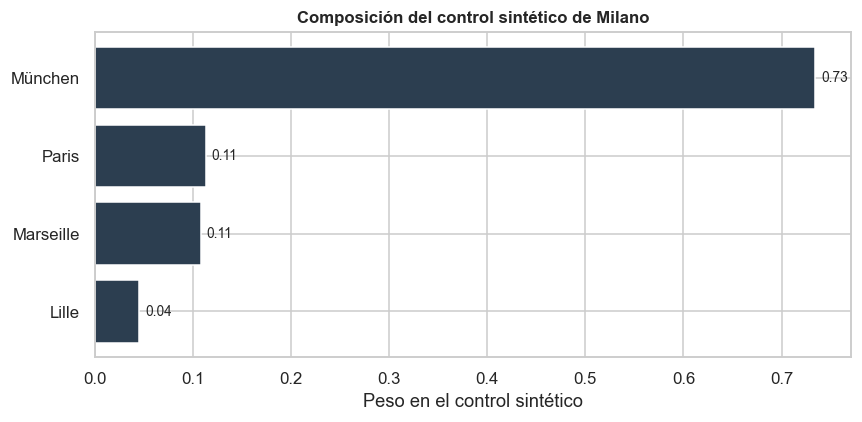

In [26]:
top = pesos[pesos > 0.01].sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top.index, top.values, color=COL_POL)
ax.set_xlabel("Peso en el control sintético")
ax.set_title(f"Composición del control sintético de {CIUDAD_TRATADA}")
for y, v in enumerate(top.values):
    ax.annotate(f"{v:.2f}", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9)
plt.show()

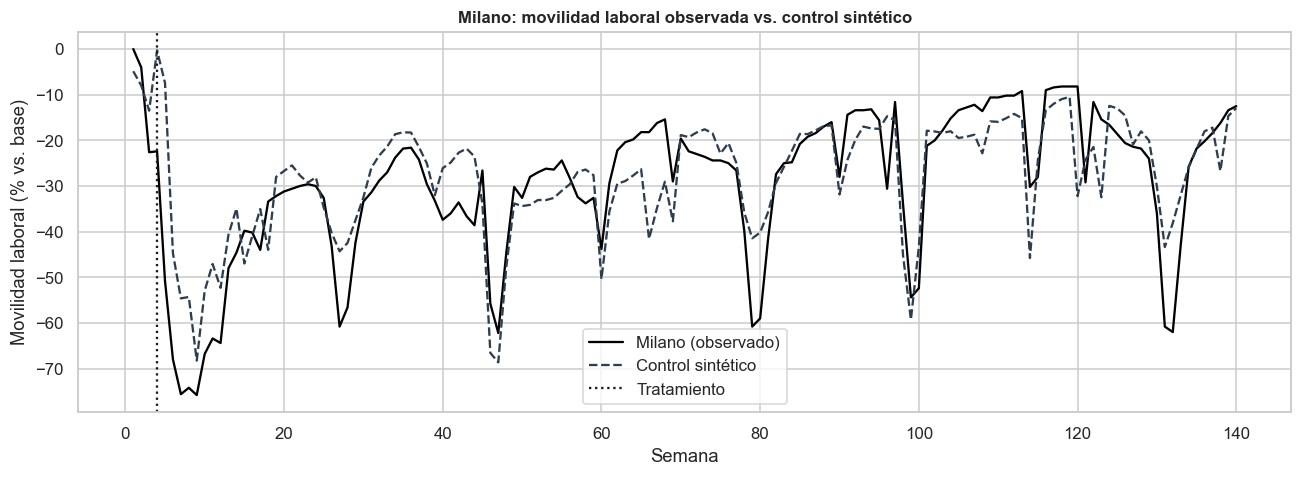

In [27]:
# Trayectoria observada de Milano frente a su control sintético
# (se grafica de forma manual para tener una sola figura con títulos correctos)
Z0_s, Z1_s = synth.dataprep.make_outcome_mats(time_period=range(1, 141))
sintetico = synth._synthetic(Z0=Z0_s)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(Z1_s.index, Z1_s.values, color="black", lw=1.5, label=f"{CIUDAD_TRATADA} (observado)")
ax.plot(sintetico.index, sintetico.values, color=COL_POL, lw=1.5, ls="--", label="Control sintético")
ax.axvline(SEMANA_TRAT, color="k", ls=":", label="Tratamiento")
ax.set_title(f"{CIUDAD_TRATADA}: movilidad laboral observada vs. control sintético")
ax.set_xlabel("Semana"); ax.set_ylabel("Movilidad laboral (% vs. base)"); ax.legend()
plt.show()

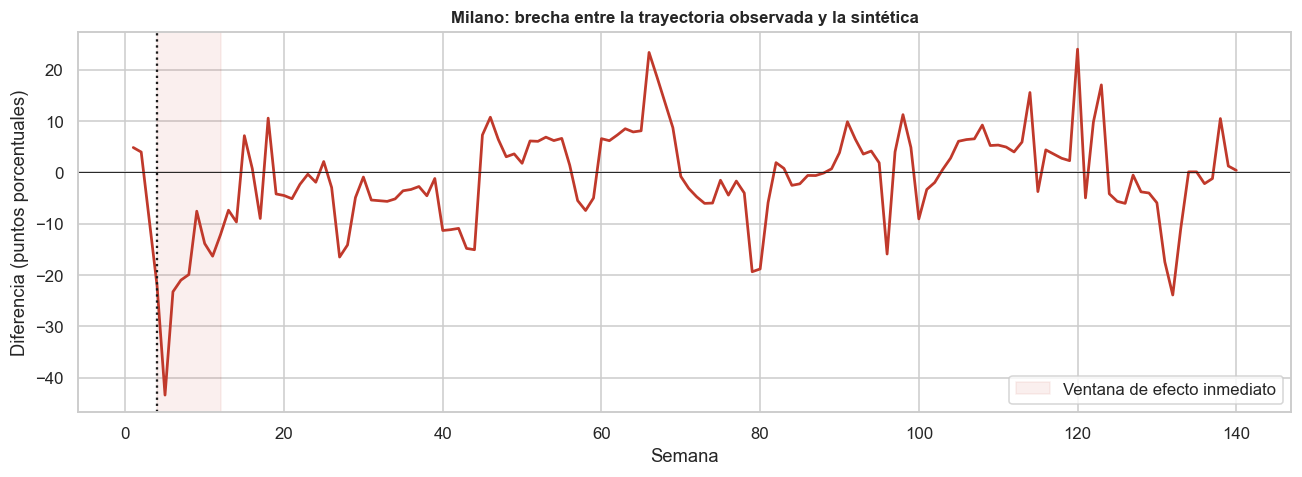

RMSPE pre-tratamiento: 6.39
Efecto medio (todo el post-tratamiento): -1.38   ee: 0.83
Efecto medio (8 semanas posteriores): -20.92   ee: 3.69


In [28]:
# La brecha ya está calculada (gap_milano); se grafica resaltando la ventana post-tratamiento
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(gap_milano.index, gap_milano.values, color=COL_MOV, lw=1.8)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(SEMANA_TRAT, color="k", ls=":")
ax.axvspan(SEMANA_TRAT, SEMANA_TRAT + 8, color="#c0392b", alpha=0.08,
           label="Ventana de efecto inmediato")
ax.set_title(f"{CIUDAD_TRATADA}: brecha entre la trayectoria observada y la sintética")
ax.set_xlabel("Semana"); ax.set_ylabel("Diferencia (puntos porcentuales)"); ax.legend()
plt.show()

att_post = synth.att(time_period=range(SEMANA_TRAT, 141))
att_8 = synth.att(time_period=range(SEMANA_TRAT, SEMANA_TRAT + 8))
print("RMSPE pre-tratamiento:", round(synth.mspe() ** 0.5, 2))
print("Efecto medio (todo el post-tratamiento):", round(att_post["att"], 2), "  ee:", round(att_post["se"], 2))
print("Efecto medio (8 semanas posteriores):", round(att_8["att"], 2), "  ee:", round(att_8["se"], 2))

### Robustez con control sintético penalizado

El control sintético clásico optimiza una matriz de importancias de predictores que puede sobreajustarse cuando el período pre-tratamiento es corto, como ocurre aquí. El control sintético penalizado de `pysyncon` regulariza el problema penalizando las diferencias entre la unidad tratada y cada donante, lo que produce pesos más estables y un cómputo mucho más rápido. Se reestima el efecto con este método como prueba de robustez; es además el estimador central que ilustra `SynthControl.ipynb`.

Pesos principales (penalizado):
Mannheim     0.5390
Paris        0.4610
Berlin       0.0000
Las Palmas   0.0000
Valencia     0.0000

RMSPE pre-tratamiento: 10.43
Efecto medio 8 semanas (penalizado): -13.41


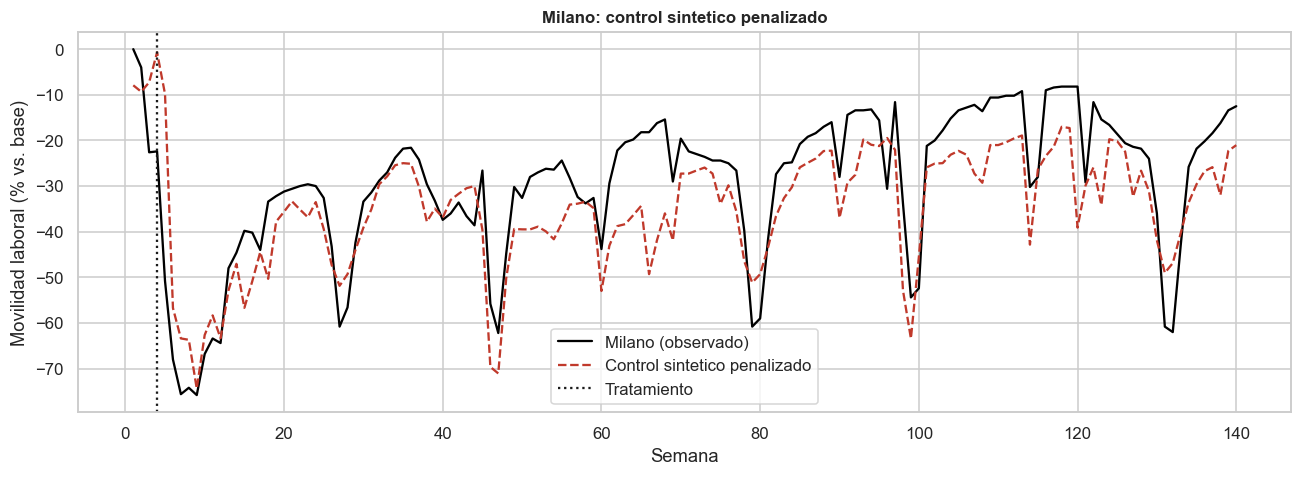

In [29]:
pen = PenalizedSynth()
pen.fit(dataprep=dataprep, lambda_=0.01)
print("Pesos principales (penalizado):")
print(pen.weights().sort_values(ascending=False).head(5).round(3).to_string())
print("\nRMSPE pre-tratamiento:", round(pen.mspe() ** 0.5, 2))
print("Efecto medio 8 semanas (penalizado):", round(pen.att(time_period=range(SEMANA_TRAT, SEMANA_TRAT + 8))["att"], 2))

# Trayectoria con el estimador penalizado (grafico manual, una sola figura)
Z0_p, Z1_p = pen.dataprep.make_outcome_mats(time_period=range(1, 141))
sintetico_pen = pen._synthetic(Z0=Z0_p)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(Z1_p.index, Z1_p.values, color="black", lw=1.5, label=f"{CIUDAD_TRATADA} (observado)")
ax.plot(sintetico_pen.index, sintetico_pen.values, color=COL_MOV, lw=1.5, ls="--", label="Control sintetico penalizado")
ax.axvline(SEMANA_TRAT, color="k", ls=":", label="Tratamiento")
ax.set_title(f"{CIUDAD_TRATADA}: control sintetico penalizado")
ax.set_xlabel("Semana"); ax.set_ylabel("Movilidad laboral (% vs. base)"); ax.legend()
plt.show()

Veemos que el modelo propuesto realiza el control de forma casi similar y aproximada a lo planteado.

### Inferencia por placebos

Con una sola unidad tratada, la inferencia se realiza reasignando ficticiamente el tratamiento a cada ciudad del *donor pool* y comparando la brecha de Milano con la distribución de brechas placebo. Si la razón entre el error de ajuste posterior y previo al tratamiento (RMSPE) de Milano es extrema respecto de la distribución de placebos, el efecto se considera significativo. La prueba se ejecuta con el control sintético penalizado, que permite reestimar el modelo para cada una de las ciudades del donor pool en pocos segundos; la unidad tratada se evalúa con el mismo estimador para que la comparación sea homogénea.

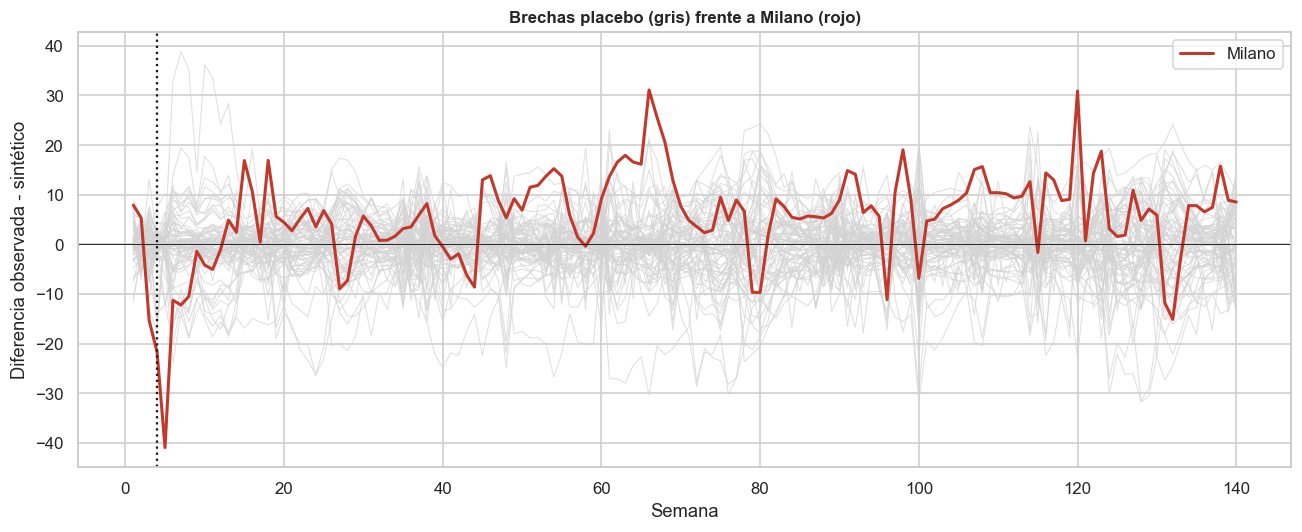

Razón RMSPE post/pre de Milano: 1.29
Posición de Milano: 25 de 73 unidades
p-valor por placebos (proporción con razón >= Milano): 0.342


In [30]:
VENT = range(SEMANA_TRAT, SEMANA_TRAT + 8)   # ventana de efecto inmediato

def ajustar_penalizado(tratada):
    sc = PenalizedSynth()
    sc.fit(dataprep=construir_dataprep(tratada, donantes), lambda_=0.01)
    return sc

def ratio_postpre(scm):
    pre = scm.mspe() ** 0.5
    post = abs(scm.att(time_period=VENT)["att"])
    return post / max(pre, 1e-6)

# Inferencia homogénea con el estimador penalizado. Milano reutiliza el ajuste "pen"
# de la celda de robustez; cada donante se reestima una sola vez (segundos en total).
gaps_placebo = {CIUDAD_TRATADA: serie_gap(pen)}
ratios = {CIUDAD_TRATADA: ratio_postpre(pen)}
for ciudad in donantes:
    try:
        sc = ajustar_penalizado(ciudad)
        gaps_placebo[ciudad] = serie_gap(sc)
        ratios[ciudad] = ratio_postpre(sc)
    except Exception:
        pass

r_milano = ratios[CIUDAD_TRATADA]
vals = np.array([v for k, v in ratios.items() if k != CIUDAD_TRATADA])
pval = (np.sum(vals >= r_milano) + 1) / (len(vals) + 1)

fig, ax = plt.subplots(figsize=(12, 5))
for ciudad, g in gaps_placebo.items():
    if ciudad == CIUDAD_TRATADA:
        continue
    ax.plot(range(1, 141), g.values, color="lightgray", lw=0.7, alpha=0.7)
ax.plot(range(1, 141), gaps_placebo[CIUDAD_TRATADA].values, color=COL_MOV, lw=2, label=CIUDAD_TRATADA)
ax.axvline(SEMANA_TRAT, color="k", ls=":"); ax.axhline(0, color="k", lw=0.6)
ax.set_title("Brechas placebo (gris) frente a Milano (rojo)")
ax.set_xlabel("Semana"); ax.set_ylabel("Diferencia observada - sintético"); ax.legend()
plt.show()

print(f"Razón RMSPE post/pre de Milano: {r_milano:.2f}")
print(f"Posición de Milano: {int(np.sum(vals >= r_milano)) + 1} de {len(vals) + 1} unidades")
print(f"p-valor por placebos (proporción con razón >= Milano): {pval:.3f}")

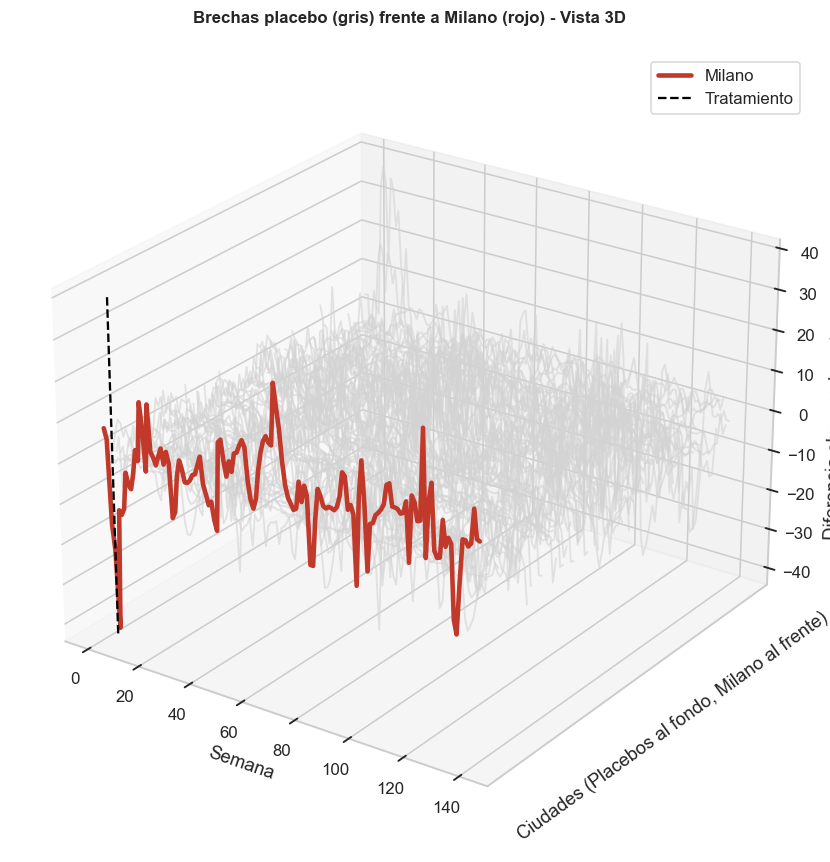

Razón RMSPE post/pre de Milano: 1.29
Posición de Milano: 25 de 73 unidades
p-valor por placebos (proporción con razón >= Milano): 0.342


In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Configurar figura 3D
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

semanas = np.arange(1, 141)

# Asignar posiciones en el eje Y para que las líneas no se pisen
y_pos = 1 

# 1. Graficar primero las ciudades donantes (placebos)
for ciudad, g in gaps_placebo.items():
    if ciudad == CIUDAD_TRATADA:
        continue
    # X = semanas, Y = índice de ciudad, Z = valores de la brecha
    ax.plot(semanas, np.full_like(semanas, y_pos), g.values, 
            color="lightgray", lw=1.2, alpha=0.6)
    y_pos += 1

# 2. Graficar Milano (Tratada) en la posición Y = 0 (al frente para destacar)
ax.plot(semanas, np.full_like(semanas, 0), gaps_placebo[CIUDAD_TRATADA].values, 
        color=COL_MOV, lw=3, label=CIUDAD_TRATADA)

# 3. Dibujar la línea del momento del tratamiento en el plano de Milano (Y=0)
# Para guiar el ojo sobre cuándo ocurrió el confinamiento
ax.plot([SEMANA_TRAT, SEMANA_TRAT], [0, 0], [ax.get_zlim()[0], ax.get_zlim()[1]], 
        color="black", linestyle="--", lw=1.5, label="Tratamiento")

# 4. Estética y etiquetas
ax.set_title("Brechas placebo (gris) frente a Milano (rojo) - Vista 3D", pad=20)
ax.set_xlabel("Semana")
ax.set_ylabel("Ciudades (Placebos al fondo, Milano al frente)")
ax.set_zlabel("Diferencia observada - sintético")

# Ajustar el ángulo de cámara (elevación y rotación azimutal)
# Puedes jugar con estos números para rotar el gráfico
ax.view_init(elev=25, azim=-55) 

# Limpiar las etiquetas del eje Y para que no muestre números aleatorios
ax.set_yticks([]) 
ax.legend()

plt.tight_layout()
plt.show()

# Imprimir los resultados estadísticos (mantienes esta parte de tu código)
print(f"Razón RMSPE post/pre de Milano: {r_milano:.2f}")
print(f"Posición de Milano: {int(np.sum(vals >= r_milano)) + 1} de {len(vals) + 1} unidades")
print(f"p-valor por placebos (proporción con razón >= Milano): {pval:.3f}")

### Discusión de los resultados

El control sintético clásico reproduce de forma razonable la trayectoria de movilidad laboral de Milano antes del confinamiento, con un pre-tratamiento moderado y un valor concentrado en ciudades alemanas y francesas (principalmente München, Paris y Marseille). Tras la intervención, la movilidad laboral observada cae claramente por debajo de la del control sintético: en las ocho semanas posteriores al confinamiento la brecha media es amplia y negativa, del orden de veinte puntos porcentuales. El control sintético penalizado confirma el signo y una magnitud de corto plazo también elevada, aunque con un ajuste pre-tratamiento peor, lo que ilustra el costo de la regularización cuando el período previo es corto.\

Ahora bien, al promediar sobre todo el horizonte posterior la brecha se reduce de manera marcada. Esto se debe a que la movilidad se recupera y, sobre todo, a que las ciudades del *donor pool* adoptaron sus propias restricciones pocas semanas después, de modo que el contrafactual deja de ser un escenario "sin política" y el contraste se diluye. La prueba de placebos es coherente: la razón entre el error posterior y el previo de Milano no se ubica en la cola de la distribución de placebos, por lo que la inferencia formal no permite descartar que una brecha de esta magnitud surja por azar.

La conclusión equilibrada es que el control sintético respalda, en dirección y en magnitud de corto plazo, la evidencia de los modelos de panel el confinamiento se asocia con una caída pronunciada de la movilidad laboral en las semanas inmediatamente posteriores pero no entrega una identificación causal limpia.

Hay un punto en el analisis del comportamiento del individuo, quizás hay datos pero no siempre nos refleja de manera exacta la realidad del momento.

## Conclusiones

Las restricciones gubernamentales redujeron de manera robusta la movilidad laboral (Esperable). El efecto del *Stringency Index* es negativo y significativo en todas las especificaciones; su magnitud depende del tratamiento del tiempo: -0.39 (FE de entidad), -0.09 (two-way FE) y, en el modelo dinámico de persistencia, -0.16 de corto plazo y -0.50 de largo plazo. Hausman y Mundlak respaldan el uso de efectos fijos; para datos semanales, el modelo dinámico con rezago de la dependiente captura la dinámica sin aplanarla. Las pruebas de Hausman y de Mundlak rechazan la ortogonalidad del componente no observado, por lo que el estimador preferido es el de efectos fijos, preferentemente con efectos de tiempo. La principal limitación de los modelos de panel es la simultaneidad dinámica entre política y movilidad. El control sintético aborda esa limitación con un diseño cuasi-experimental: muestra una caída pronunciada de la movilidad laboral de Milano en las semanas inmediatamente posteriores al confinamiento, coherente en dirección y magnitud de corto plazo con la evidencia de panel. No obstante, la inferencia por placebos no resulta concluyente, debido al corto período pre-tratamiento disponible y a la adopción casi simultánea de restricciones en las ciudades de control. En conjunto, la evidencia apunta de forma consistente a que las restricciones redujeron la movilidad laboral, con una estimación de panel robusta y un ejercicio de control sintético que ilustra tanto el efecto de corto plazo como los límites de identificación impuestos por los datos.